In [48]:
import torch
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
from models import Emotion_Models
from tqdm import tqdm
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, classification_report
from torch import optim
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

In [49]:
from config import Config as cf
from datasets import Emotions_Dataset, show_single_img, show_batch_dataset
import cv2

In [50]:
print(cf.DEVICE)

cuda


In [51]:
transform_train = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.6),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.CoarseDropout(
        num_holes_range= (1, 5), 
        p=0.5
    ), 
    A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255),
    ToTensorV2(), 
])

transform_test = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255),
    ToTensorV2(), 
])



c:\Users\sanng\miniconda3\envs\vision_env\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [52]:
dataset_train = Emotions_Dataset(cf.TRAIN_PATH, transform= transform_train)
dataset_test = Emotions_Dataset(cf.TEST_PATH, transform = transform_test)

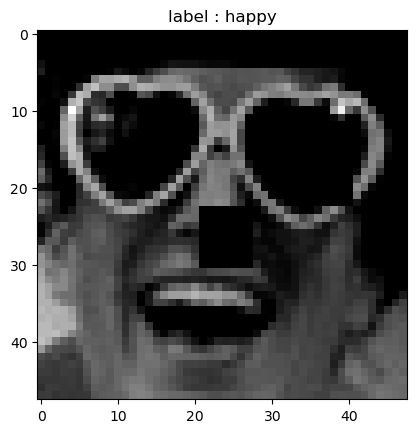

In [53]:
dataset_train_item = dataset_train[random.randint(0,len(dataset_train))]
show_single_img(dataset_train_item)

In [54]:
def sampler_init(dataset : Emotions_Dataset):
    weight = [1/dataset.len_class[i[1]] for i in dataset.sample]
    sampler = WeightedRandomSampler(
        weights= weight,
        num_samples= len(dataset),
        replacement= True
    )
    return sampler

In [55]:
train_loader = DataLoader(
    dataset= dataset_train,
    batch_size= 128,
    sampler= sampler_init(dataset_train),
    pin_memory= True,
    drop_last= True,
    num_workers= 8,
    prefetch_factor= 4,
    persistent_workers=True

)


test_loader = DataLoader(
    dataset= dataset_test,
    batch_size=128,
    sampler=sampler_init(dataset_test),
    pin_memory= True,
    drop_last= False
)

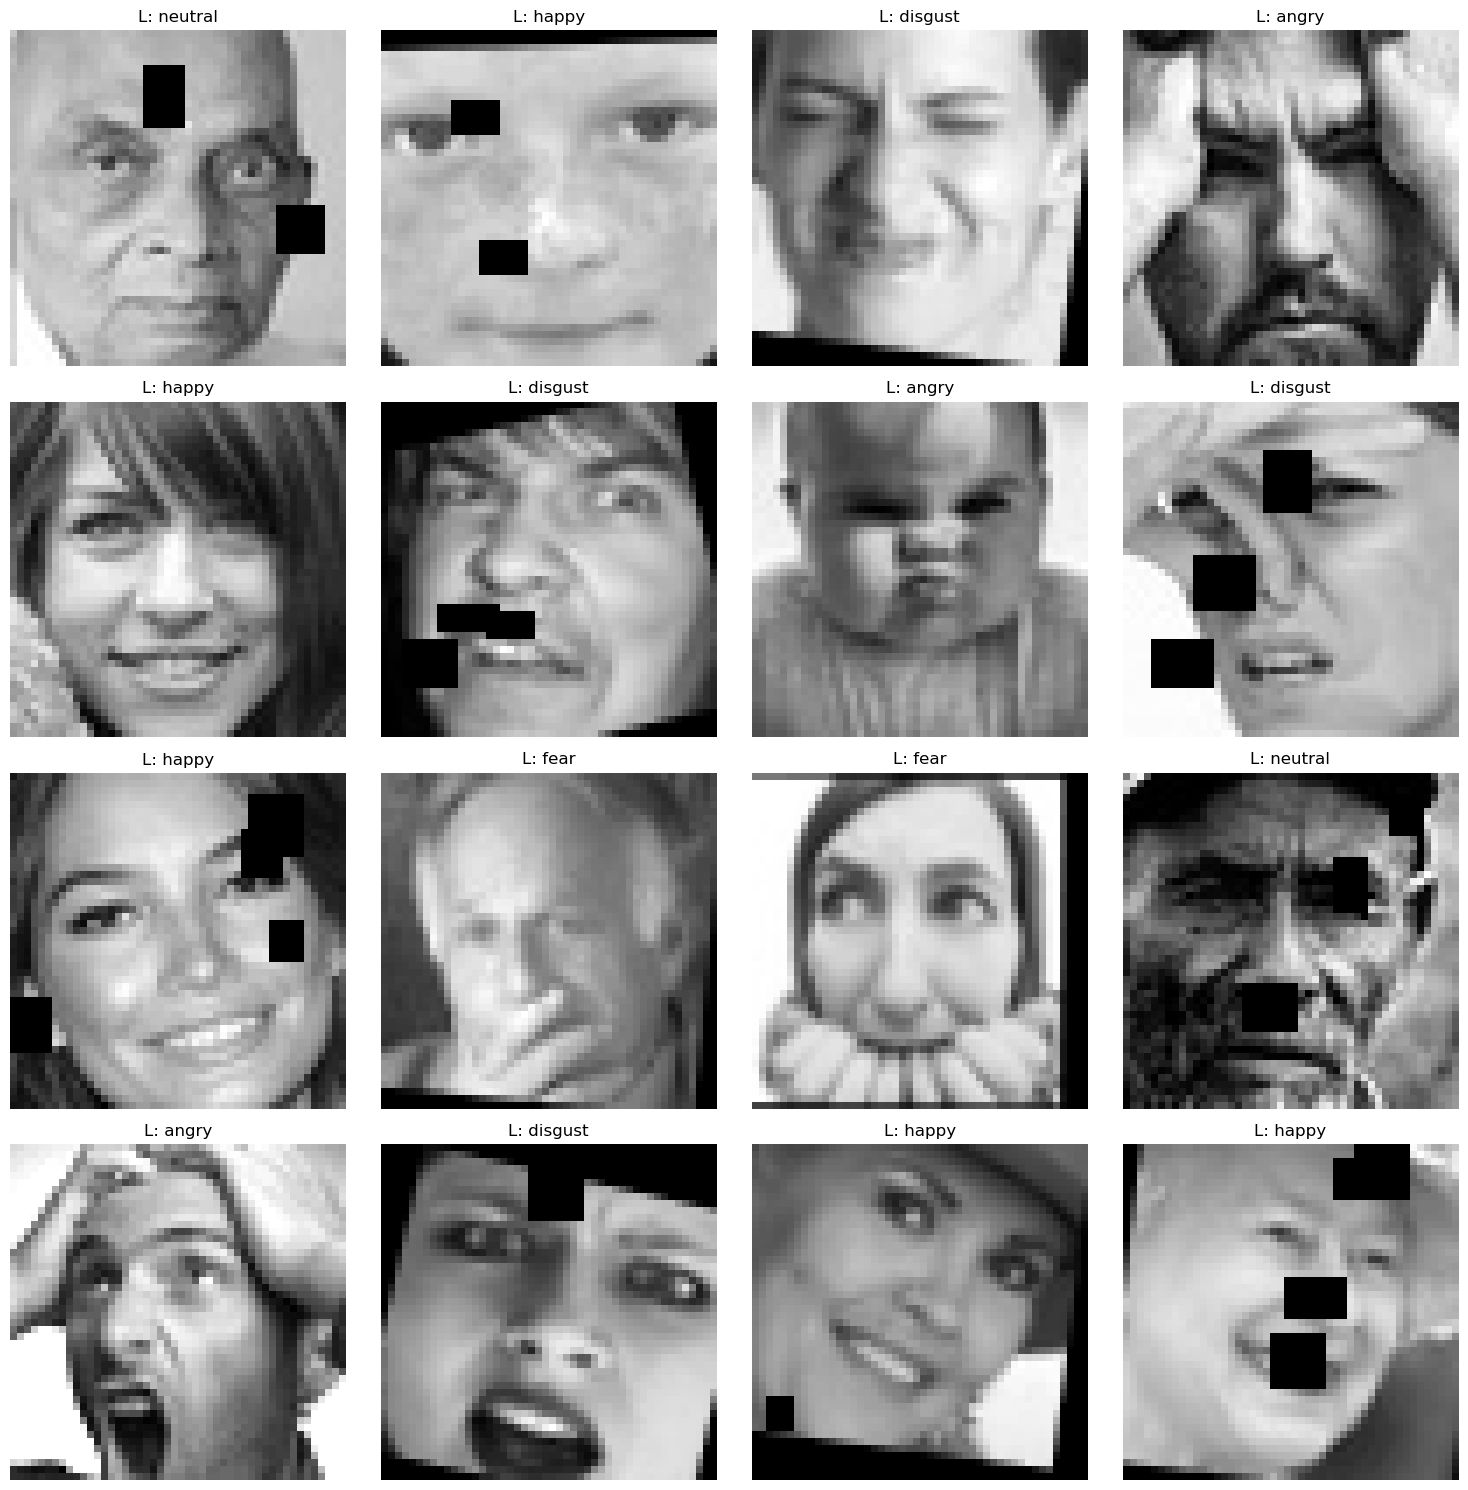

In [56]:
show_batch_dataset(train_loader)

In [57]:
model = Emotion_Models(classes= 7)
# model.save_model()
model.load_model(device= cf.DEVICE)
# model = model.to(config.DEVICE)

In [58]:
def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    accuracy = accuracy_score(all_labels, all_preds)

    return precision, recall, f1, accuracy

In [ ]:
def training_models(device, model, train_loader, test_loader, num_epochs=50, compile_model=False):

    model = model.to(device)

    if compile_model and hasattr(torch, "compile"):
        model = torch.compile(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer, 
            max_lr=1e-3, 
            steps_per_epoch=len(train_loader), 
            epochs=num_epochs,
            pct_start=0.1
        )

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'test_f1': [],
        'lr' : [],
        'precision' : [],
        'recall' : []
    }

    best_f1 = 0.0

    for epoch in range(num_epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, (inputs, labels) in enumerate(pbar):

            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()

            scheduler.step()

            running_loss += loss.detach().item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.6f}")

        
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        precision, recall, f1, accuracy = evaluate(model, test_loader, device)

        current_lr = scheduler.get_last_lr()[0] 

        print(
            f"Epoch {epoch+1} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Test Acc: {accuracy:.4f} | "
            f"F1: {f1:.4f} | "
            f"LR: {current_lr:.6f}"
        )

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(accuracy)
        history['test_f1'].append(f1)
        history['precision'].append(precision)
        history['recall'].append(recall)
        history['lr'].append(current_lr) 

        if f1 > best_f1:
            print("New Best Model Saved")
            best_f1 = f1
            model.save_model(path= 'models/best_model.pth')

    return history

In [61]:
history = training_models(
    device= cf.DEVICE, 
    model= model, 
    train_loader= train_loader, 
    test_loader= test_loader, 
    num_epochs=60
    )

Epoch 1/60: 100%|██████████| 224/224 [00:54<00:00,  4.13it/s, loss=1.6375, lr=0.000104]


Epoch 1 | Train Loss: 1.7251 | Train Acc: 0.3524 | Test Acc: 0.2703 | F1: 0.1974 | LR: 0.000104


Epoch 2/60: 100%|██████████| 224/224 [00:54<00:00,  4.14it/s, loss=1.4708, lr=0.000280]


Epoch 2 | Train Loss: 1.5620 | Train Acc: 0.4482 | Test Acc: 0.3667 | F1: 0.3611 | LR: 0.000280


Epoch 3/60: 100%|██████████| 224/224 [00:53<00:00,  4.15it/s, loss=1.4871, lr=0.000521]


Epoch 3 | Train Loss: 1.4907 | Train Acc: 0.4811 | Test Acc: 0.3526 | F1: 0.3258 | LR: 0.000521


Epoch 4/60: 100%|██████████| 224/224 [00:54<00:00,  4.14it/s, loss=1.3938, lr=0.000761]


Epoch 4 | Train Loss: 1.4260 | Train Acc: 0.5212 | Test Acc: 0.3899 | F1: 0.4073 | LR: 0.000761


Epoch 5/60:  48%|████▊     | 108/224 [00:26<00:28,  4.08it/s, loss=1.2566, lr=0.000857]


KeyboardInterrupt: 

In [ ]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(18, 12))

    # --- 1. Đồ thị Loss ---
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], 'r-o', label='Train Loss', markersize=4)
    plt.title('Training Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # --- 2. Đồ thị Accuracy ---
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['train_acc'], 'g-o', label='Train Acc', markersize=4)
    plt.plot(epochs, history['test_acc'], 'b-s', label='Test Acc', markersize=4)
    plt.title('Training & Test Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # --- 3. Đồ thị Precision, Recall, F1 ---
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history['test_f1'], 'm-v', label='F1-Score')
    plt.plot(epochs, history['precision'], 'c-x', label='Precision')
    plt.plot(epochs, history['recall'], 'y-d', label='Recall')
    plt.title('Detailed Metrics (Test Set)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # --- 4. Đồ thị Learning Rate ---
    plt.subplot(2, 2, 4)
    plt.plot(epochs, history['lr'], 'k-', label='Learning Rate')
    plt.title('Learning Rate Schedule (OneCycleLR)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('LR Value')
    # Sử dụng format khoa học cho trục Y vì LR thường rất nhỏ
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout() # Tránh các tiêu đề đè lên nhau
    plt.show()

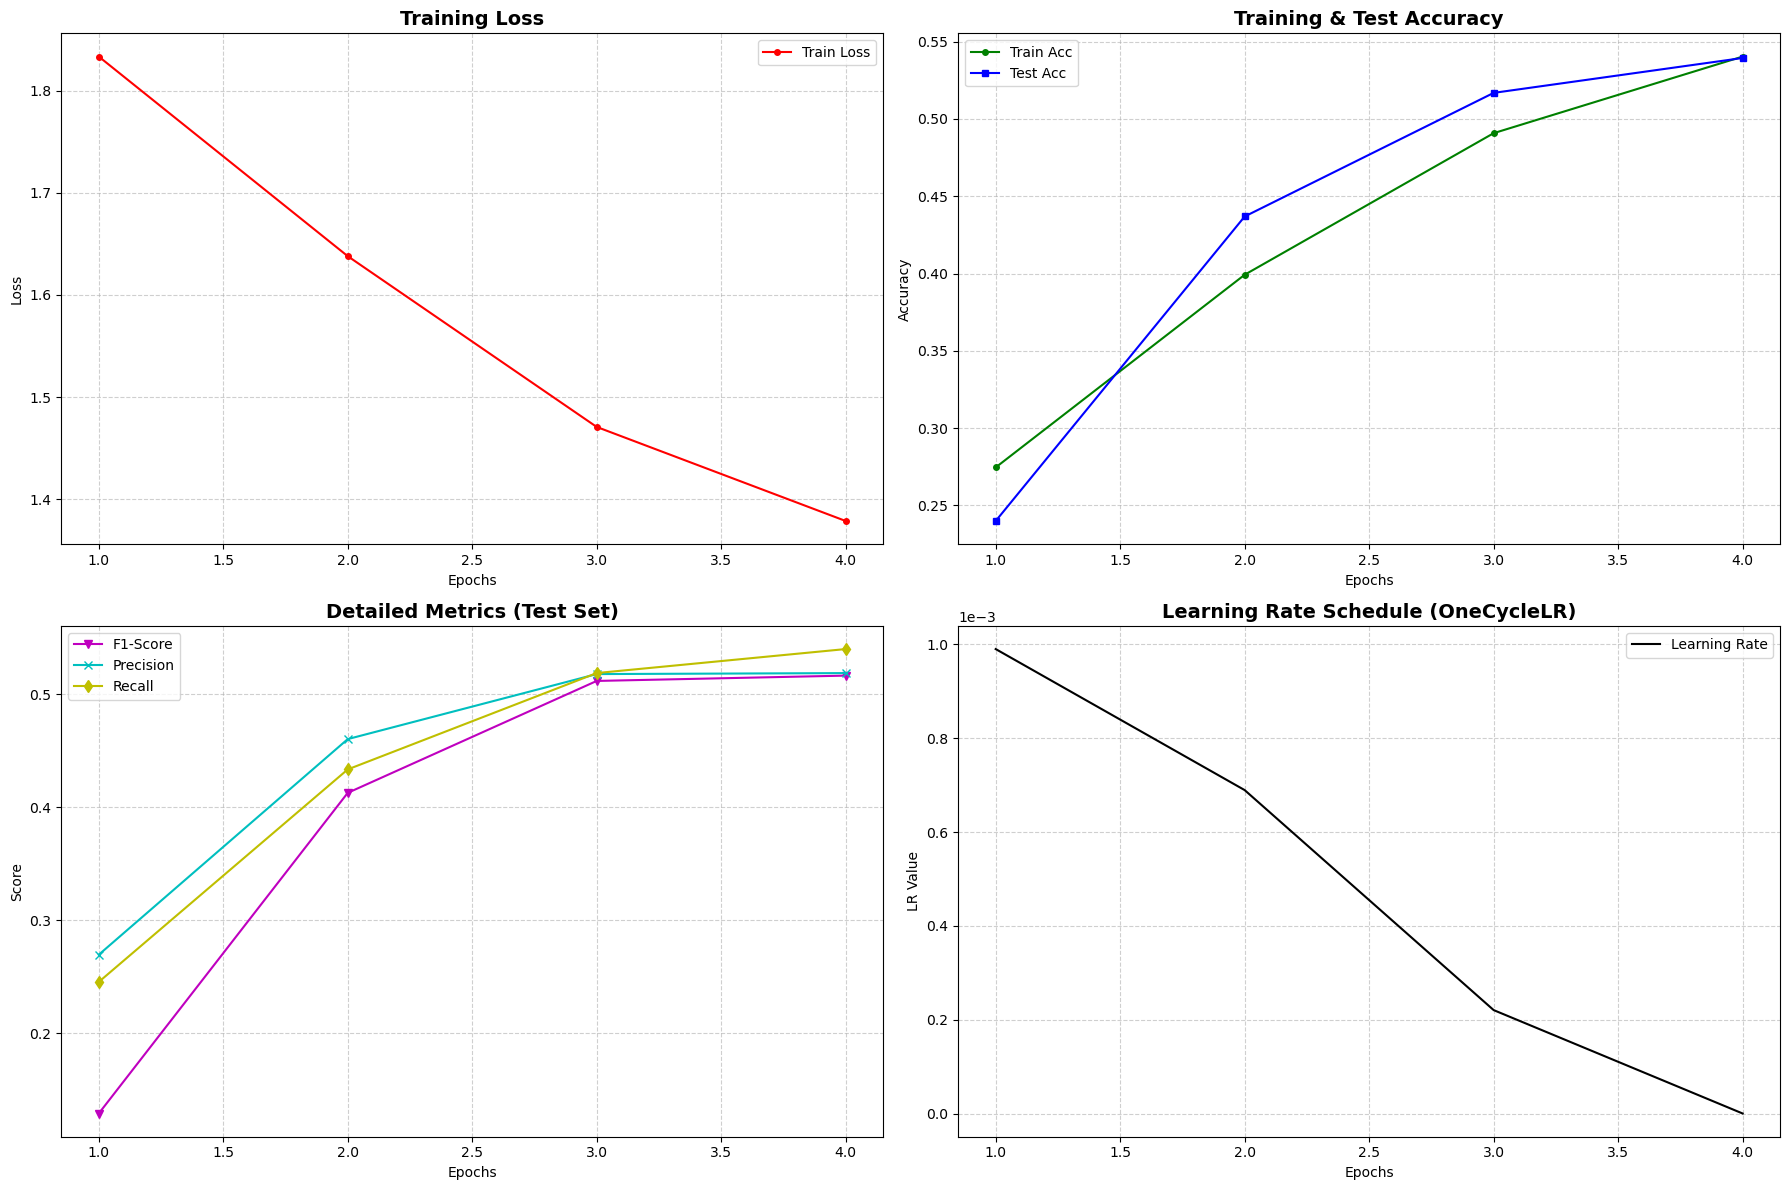

In [ ]:
plot_history(history)

In [ ]:
def plot_confusion_matrix(model, test_loader, device, classes_name):
    model.to(device)
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    

    print("BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):\n")
    print(classification_report(all_labels, all_preds, target_names=classes_name))


    cm = confusion_matrix(all_labels, all_preds)
    

    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=classes_name, yticklabels=classes_name)
    
    plt.title('Confusion Matrix (Unit: %)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

In [ ]:
model = Emotion_Models(classes= 7)
model.load_model(path = 'models\\best_model.pth')

BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):

              precision    recall  f1-score   support

       angry       0.40      0.37      0.38      1020
     disgust       0.66      0.73      0.69      1004
        fear       0.36      0.10      0.16      1016
       happy       0.71      0.79      0.75       986
     neutral       0.48      0.60      0.53      1068
         sad       0.39      0.43      0.41      1035
    surprise       0.66      0.80      0.72      1049

    accuracy                           0.55      7178
   macro avg       0.52      0.55      0.52      7178
weighted avg       0.52      0.55      0.52      7178



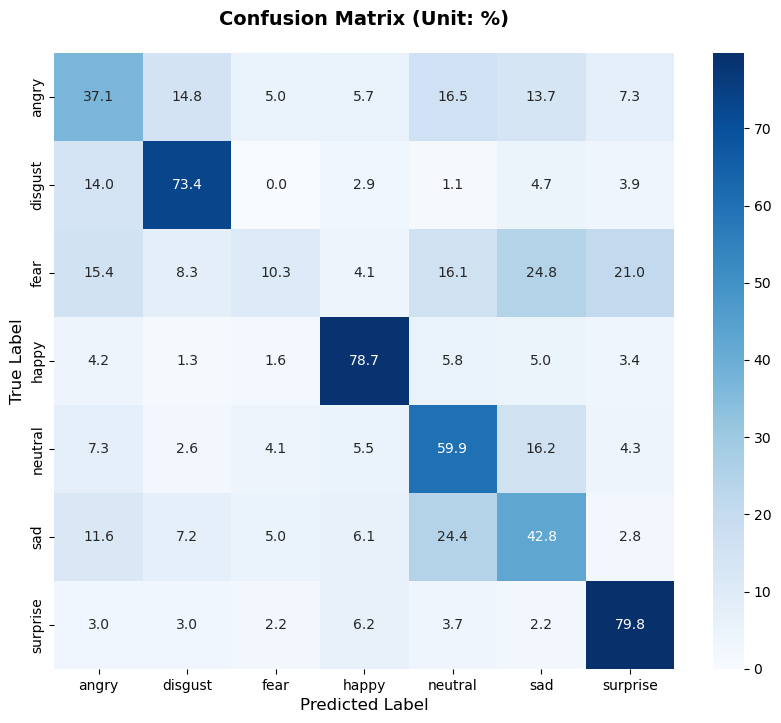

In [ ]:
plot_confusion_matrix(model, test_loader,device= cf.DEVICE, classes_name = cf.CLASSES)